# Demo 1a: Loading Medical Images (DICOM & Standard Formats)

Medical images come in several formats — DICOM (the clinical standard),
PNG, and JPEG. This demo walks through loading each and converting to
tensors that PyTorch can work with.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Medical imaging
import pydicom
from pydicom.data import get_testdata_file

# PyTorch
import torch
from torchvision import transforms

## 1. Loading a DICOM File

DICOM files contain both **pixel data** and **metadata** (patient info,
acquisition parameters, etc.). Let's use one of pydicom's built-in test files.

In [2]:
# Load a DICOM test file
dcm_path = get_testdata_file("CT_small.dcm")
ds = pydicom.dcmread(dcm_path)

# Inspect metadata
print(f"Modality:        {ds.Modality}")
print(f"Patient Name:    {ds.PatientName}")
print(f"Image Size:      {ds.Rows} x {ds.Columns}")
print(f"Bits Allocated:  {ds.BitsAllocated}")
print(f"Pixel Spacing:   {getattr(ds, 'PixelSpacing', 'N/A')}")

Modality:        CT
Patient Name:    CompressedSamples^CT1
Image Size:      128 x 128
Bits Allocated:  16
Pixel Spacing:   [0.661468, 0.661468]


Pixel array shape: (128, 128)
Pixel dtype:       int16
Value range:       [128, 2191]


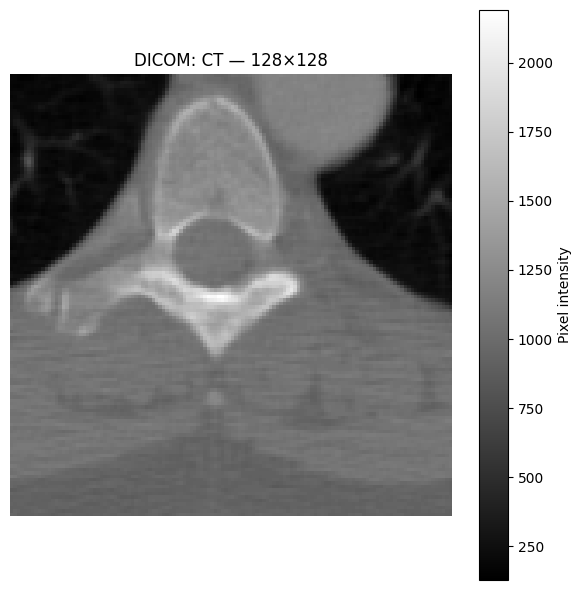

In [3]:
# Extract pixel data
pixels = ds.pixel_array
print(f"Pixel array shape: {pixels.shape}")
print(f"Pixel dtype:       {pixels.dtype}")
print(f"Value range:       [{pixels.min()}, {pixels.max()}]")

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(pixels, cmap="gray")
plt.title(f"DICOM: {ds.Modality} — {ds.Rows}×{ds.Columns}")
plt.colorbar(label="Pixel intensity")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Normalizing DICOM Pixel Values

DICOM pixel values can be in many ranges depending on the modality and bit
depth. We need to normalize them to a standard range before using them with
PyTorch.

In [ ]:
# Normalize to [0, 1] range
pixels_float = pixels.astype(np.float32)
pixels_norm = (pixels_float - pixels_float.min()) / (
    pixels_float.max() - pixels_float.min()
)
print(f"Normalized range: [{pixels_norm.min():.2f}, {pixels_norm.max():.2f}]")

# Convert to PIL Image (expects uint8 or float32 in [0, 1])
img_pil = Image.fromarray((pixels_norm * 255).astype(np.uint8))
print(f"PIL Image mode: {img_pil.mode}, size: {img_pil.size}")

Normalized range: [0.00, 1.00]
PIL Image mode: L, size: (128, 128)


## 3. Loading Standard Image Formats

PNG and JPEG files are straightforward with Pillow.

In [5]:
# If you have a local chest X-ray image, load it like this:
# img = Image.open("chest_xray.png")

# For this demo, we'll create a sample image from the DICOM data
img = img_pil  # our DICOM converted to PIL

print(f"Image mode: {img.mode}")
print(f"Image size: {img.size}")  # (width, height) in PIL

# Convert grayscale to RGB (needed for pretrained models)
img_rgb = img.convert("RGB")
print(f"RGB image mode: {img_rgb.mode}")

Image mode: L
Image size: (128, 128)
RGB image mode: RGB


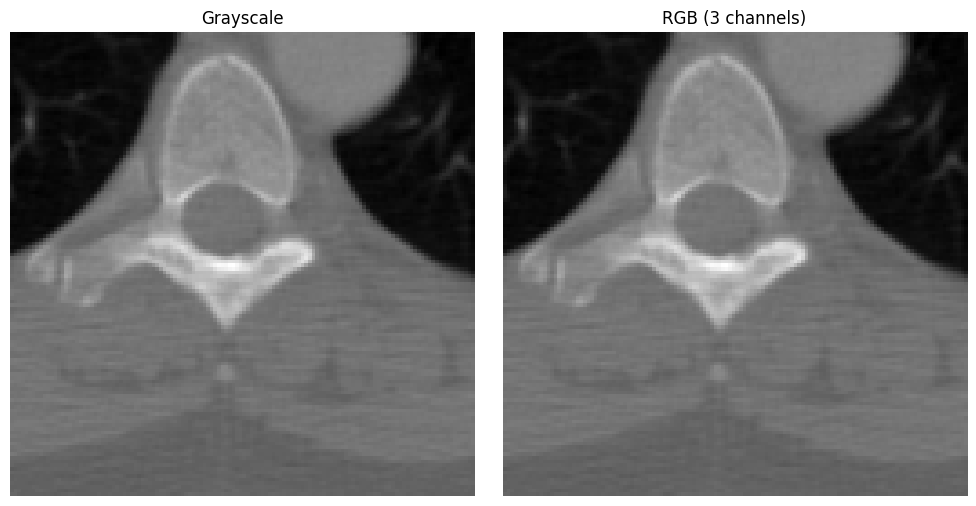

In [6]:
# Display side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(img_rgb)
axes[1].set_title("RGB (3 channels)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Converting to PyTorch Tensors

PyTorch expects tensors in **(C, H, W)** format — channels first. The
`ToTensor()` transform handles the conversion and scales pixel values from
[0, 255] to [0.0, 1.0].

In [ ]:
to_tensor = transforms.ToTensor()

# Grayscale → tensor
tensor_gray = to_tensor(img)
print(f"Grayscale tensor shape: {tensor_gray.shape}")  # (1, H, W)
print(f"Value range: [{tensor_gray.min():.3f}, {tensor_gray.max():.3f}]")

# RGB → tensor
tensor_rgb = to_tensor(img_rgb)
print(f"RGB tensor shape: {tensor_rgb.shape}")  # (3, H, W)
print(f"Value range: [{tensor_rgb.min():.3f}, {tensor_rgb.max():.3f}]")

Grayscale tensor shape: torch.Size([1, 128, 128])
Value range: [0.000, 1.000]
RGB tensor shape: torch.Size([3, 128, 128])
Value range: [0.000, 1.000]


## 5. Visualizing the Conversion Pipeline

Each step changes the data format and value range. Seeing them side by
side makes the pipeline concrete.

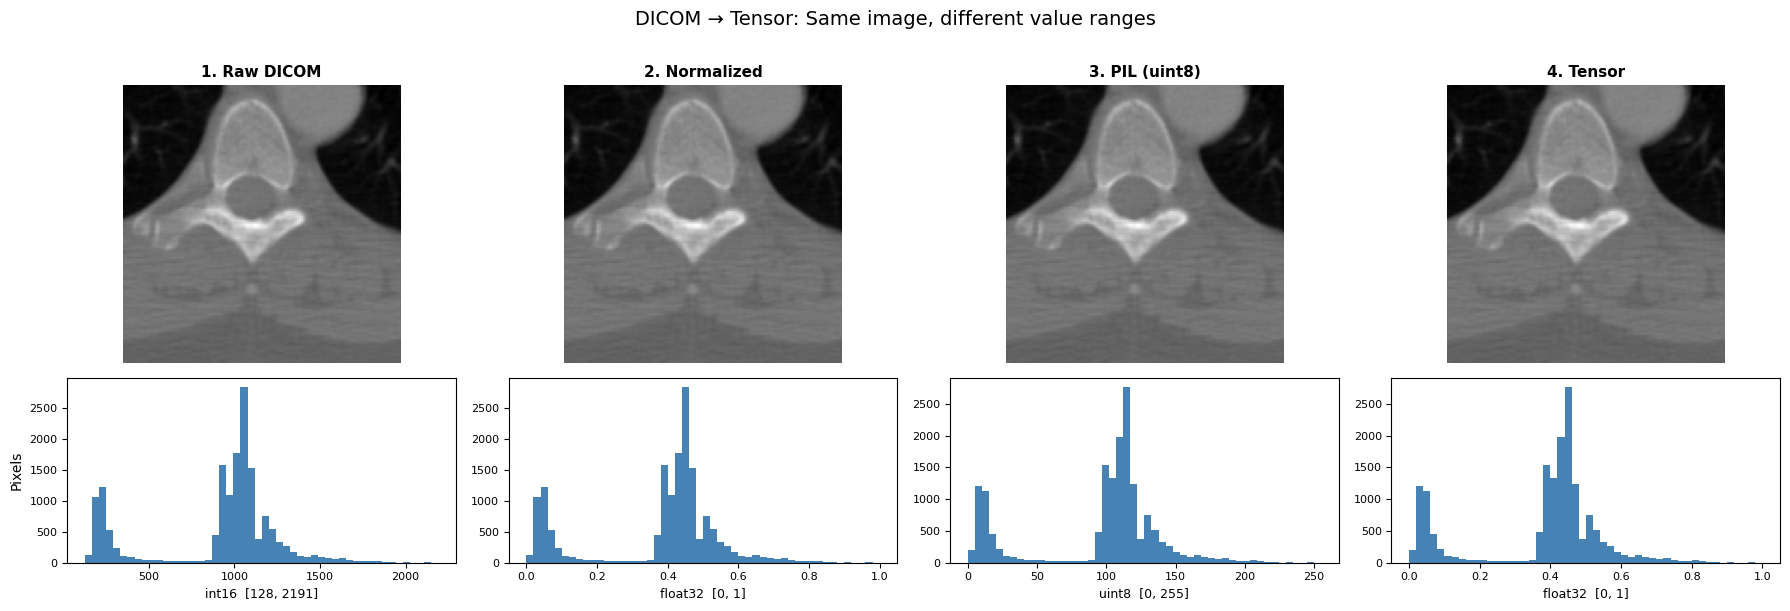

In [ ]:
# The images look identical — the pipeline preserves visual content.
# What actually changes is the VALUE RANGE and DATA TYPE at each step.
# Histograms make that visible.

stages = [
    ("1. Raw DICOM", pixels.ravel(), f"{pixels.dtype}"),
    ("2. Normalized", pixels_norm.ravel(), "float32"),
    ("3. PIL (uint8)", np.array(img).ravel(), "uint8"),
    ("4. Tensor", tensor_gray.numpy().ravel(), "float32"),
]

fig, axes = plt.subplots(
    2, 4, figsize=(18, 6), gridspec_kw={"height_ratios": [3, 2]}
)

for i, (title, vals, dtype) in enumerate(stages):
    # Top row: the image (always looks the same — that's the point)
    axes[0, i].imshow(pixels_norm, cmap="gray")
    axes[0, i].set_title(title, fontsize=11, fontweight="bold")
    axes[0, i].axis("off")

    # Bottom row: histogram shows the real difference
    axes[1, i].hist(vals, bins=50, color="steelblue", edgecolor="none")
    axes[1, i].set_xlabel(
        f"{dtype}  [{vals.min():.4g}, {vals.max():.4g}]", fontsize=9
    )
    axes[1, i].set_ylabel("Pixels" if i == 0 else "")
    axes[1, i].tick_params(labelsize=8)

plt.suptitle(
    "DICOM → Tensor: Same image, different value ranges", fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

Notice all four panels look identical — that's the point. A good conversion
pipeline preserves the visual content while changing the **data representation**
underneath. What differs at each step:

- **Raw DICOM** — 16-bit integers in scanner-specific units (e.g., Hounsfield units for CT). Use this when you need the original clinical values for diagnosis or windowing.
- **Normalized [0, 1]** — float32 scaled to a standard range. Required before feeding data into most neural networks, which expect small, bounded inputs.
- **PIL Image (uint8)** — 8-bit integers in [0, 255]. The standard format for `torchvision.transforms`, image I/O (`save`/`load`), and display libraries.
- **PyTorch Tensor (C, H, W)** — float32, channels-first. This is what `DataLoader`, loss functions, and model layers actually consume.

Each format exists because a different part of the pipeline needs it.
Getting the conversions wrong (e.g., feeding uint8 to a model expecting [0, 1],
or losing precision by normalizing too early) is one of the most common silent
bugs in medical imaging pipelines.

## What's Next?

For more advanced medical imaging pipelines (3D volumes, CT windowing,
DICOM series handling), check out [MONAI](https://monai.io/) — a PyTorch
framework built specifically for healthcare imaging.
